In [181]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import ShortTimeFFT, get_window
from scipy.signal.windows import gaussian, tukey

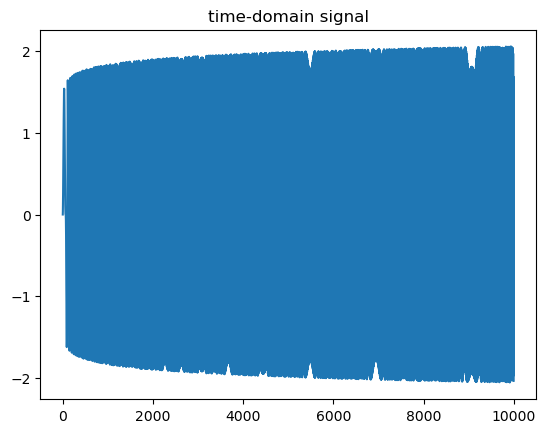

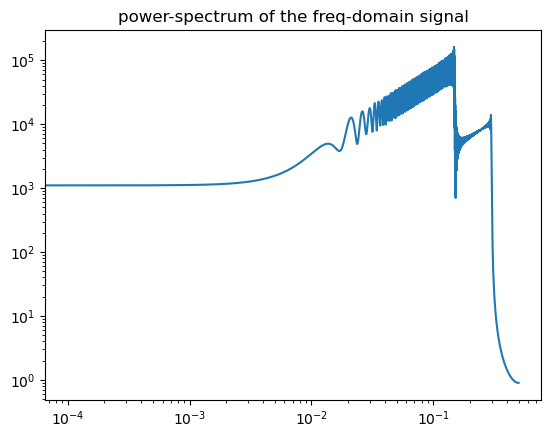

In [202]:
dt = 1.0 #time step
Tf = 10000 #final time

t_arr = np.arange(0.0,Tf,dt)
N = len(t_arr)

#sinusoid with time-varying frequency and amplitude as the array to be transformed
ffinal = 0.001 #final frequency. This is the maximum frequency in our signal according to the model, and must be << 1/dt
omega = (2*np.pi*ffinal * (t_arr[::-1])**(0.5))[::-1] #time-varying frequency
Amp = 1.0 * t_arr**(0.05) # #time-varying amplitude
x = Amp * np.sin(omega * t_arr) + Amp/2 * np.sin(2 * omega * t_arr) #array to be stft'd: one-or-two sine-modes

#visualize the signal in time and frequency domains separately
plt.plot(t_arr, x)
plt.title("time-domain signal")
plt.show()

freq = np.fft.rfftfreq(len(x), d = dt)
xtilde = np.fft.rfft(x)

plt.loglog(freq, np.abs(xtilde)**2)
plt.title("power-spectrum of the freq-domain signal")
plt.show()

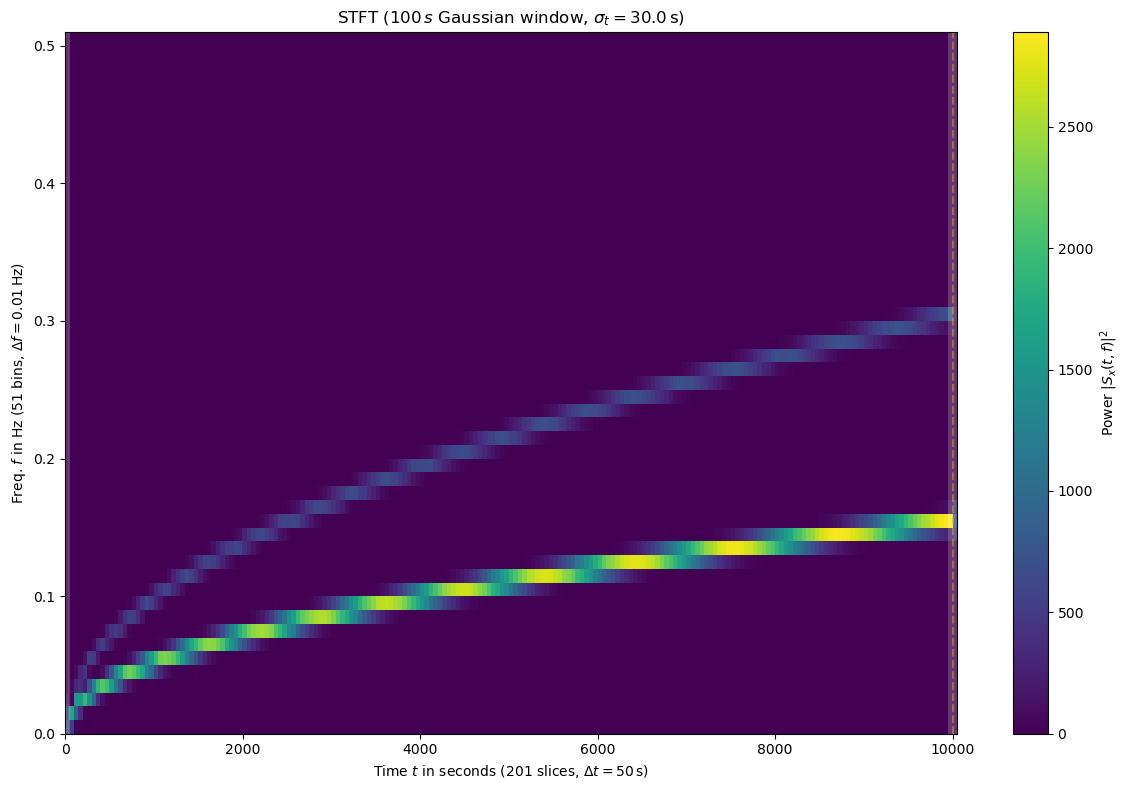

In [203]:
#performing the stft. Code stolen from https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.ShortTimeFFT.html#scipy.signal.ShortTimeFFT

fs = 1/dt #sampling frequency of the time series

g_std = 30  # standard deviation for Gaussian window in samples
window = gaussian(100, std=g_std, sym=True)  # symmetric Gaussian window

SFT = ShortTimeFFT(win = window, hop = 50, fs = fs)
Sx = SFT.stft(x)

fig1, ax1 = plt.subplots(figsize=(12., 8.))  # enlarge plot a bit
t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
ax1.set_title(rf"STFT ({SFT.m_num*SFT.T:g}$\,s$ Gaussian window, " +
              rf"$\sigma_t={g_std*SFT.T}\,$s)")
ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
               rf"$\Delta t = {SFT.delta_t:g}\,$s)",
        ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
               rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
        xlim=(t_lo, t_hi))

im1 = ax1.imshow(abs(Sx)**2, origin='lower', aspect='auto',
                 extent=SFT.extent(N), cmap='viridis')

fig1.colorbar(im1, label=r"Power $|S_x(t, f)|^2$")

# Shade areas where window slices stick out to the side:
for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                 (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
    ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
    ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

#ax1.set_ylim([0.0,0.2])
fig1.tight_layout()
plt.show()

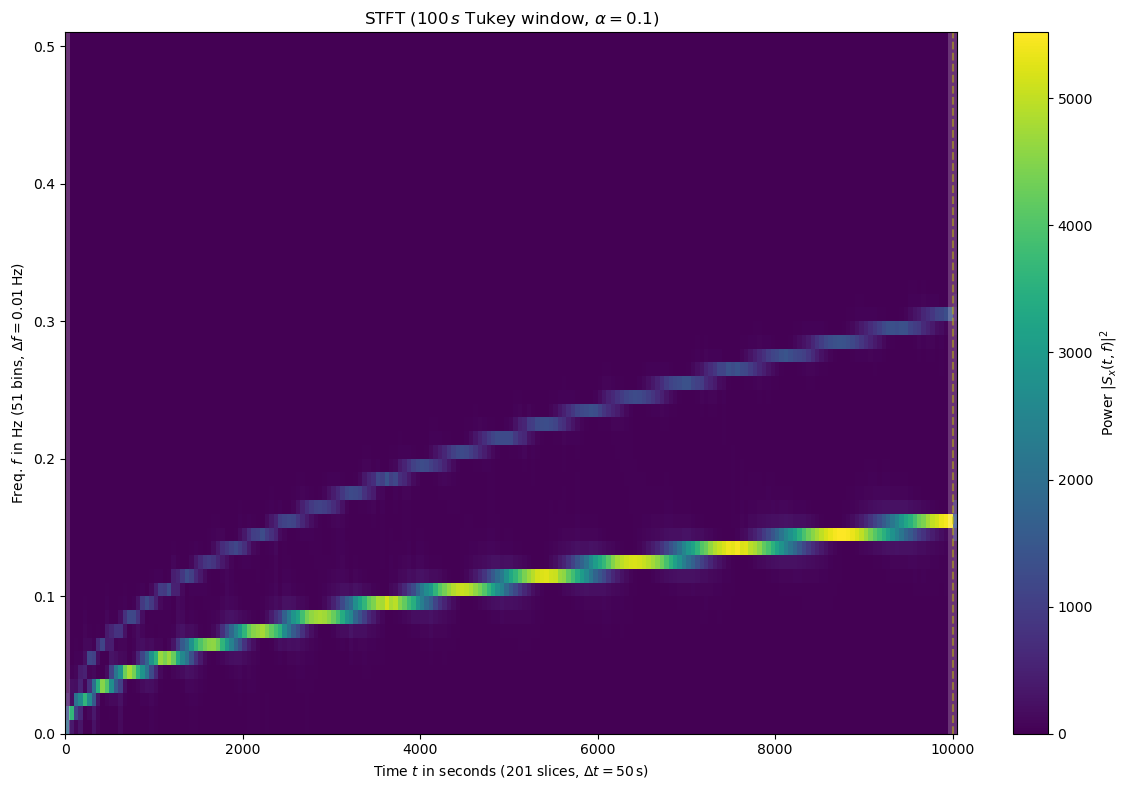

In [194]:
#using a tukey window instead

fs = 1/dt #sampling frequency of the time series

alpha = 0.1
window = tukey(M = 100, alpha=alpha, sym=True)  # tukey window

SFT = ShortTimeFFT(win = window, hop = 50, fs = fs)
Sx = SFT.stft(x)

fig1, ax1 = plt.subplots(figsize=(12., 8.))  # enlarge plot a bit
t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
ax1.set_title(rf"STFT ({SFT.m_num*SFT.T:g}$\,s$ Tukey window, " +
              rf"$\alpha={alpha}$)")
ax1.set(xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, " +
               rf"$\Delta t = {SFT.delta_t:g}\,$s)",
        ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, " +
               rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
        xlim=(t_lo, t_hi))

im1 = ax1.imshow(abs(Sx)**2, origin='lower', aspect='auto',
                 extent=SFT.extent(N), cmap='viridis')

fig1.colorbar(im1, label=r"Power $|S_x(t, f)|^2$")

# Shade areas where window slices stick out to the side:
for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
                 (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
    ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.2)
for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line:
    ax1.axvline(t_, color='y', linestyle='--', alpha=0.5)

#ax1.set_ylim([0.0,0.2])
fig1.tight_layout()
plt.show()